# GoEmotions: A Deep Dive into Multi-Label Emotion Classification

## 1. Introduction and Academic Context

Emotion analysis is a critical task in Natural Language Processing (NLP) that goes beyond simple sentiment (positive/negative) to identify specific affective states. Applications range from mental health monitoring and customer service optimization to human-computer interaction.

In this research project, we utilize the **GoEmotions** dataset—the largest curated dataset for emotion classification—to build and evaluate multiple modeling approaches.

### Objectives
- **Exploratory Data Analysis (EDA)**: Understand the distribution and nuances of the 28 emotion categories.
- **Baseline Modeling**: Establish a performance floor using traditional NLP techniques (TF-IDF + Logistic Regression).
- **SOTA Comparison**: Evaluate performance against State-of-the-Art Transformer models (RoBERTa/DistilBERT).
- **Evaluation and Error Analysis**: Quantify model reliability and identify persistent challenges in emotion disambiguation.

### 1.1 Library Imports and Reproducibility

We begin by importing the necessary scientific libraries and our custom source modules. Setting a random seed ensures results are reproducible across different runs.

In [4]:
pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   - -------------------------------------- 3.4/114.6 MB 24.5 MB/s eta 0:00:05
   ---- ----------------------------------- 12.6/114.6 MB 34.8 MB/s eta 0:00:03
   ------- -------------------------------- 21.5/114.6 MB 37.5 MB/s eta 0:00:03
   --------- ------------------------------ 28.3/114.6 MB 36.5 MB/s eta 0:00:03
   ----------- ---------------------------- 34.1/114.6 MB 37.2 MB/s eta 0:00:03
   --------------- ------------------------ 43.3/114.6 MB 36.2 MB/s eta 0:00:02
   ------------------ --------------------- 52.4/114.6 MB 37.2 MB/s eta 0:00:02
   -------------------- ------------------- 59.0/114.6 MB 36.2 MB/s eta 0:00:02
   ---------------------- ----------------- 65.0/114.6 MB 35.8 MB/s eta 0:00:02
   ------------------------- -------------- 72.1/114.6 MB 35.3 MB/s eta 0:00:02
   --------------------------- ------------ 79.2/114.6 MB 35.3 MB/s eta 0:00:02
   ------------------------------ --------- 86.0/1

In [6]:
pip install transformers

  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached transformers-5.5.4-py3-none-any.whl (10.2 MB)
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 645.5/645.5 kB 11.4 MB/s  0:00:00
Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl (3.7 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

  Attempting uninstall: regex

    Found existing installation: regex 2025.9.1

    Uninstalling regex-2025.9.1:

      Successfully uninstalled regex-2025.9.1

   ------ --------------------------------- 1/6 [regex]
   -------------------- ------------------- 3/6 [huggingface-hub]
   -------------------- ---------

In [7]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score

# Add the project root to path for src imports
sys.path.append('..')

from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataframe, split_data
from src.train import train_baseline, train_transformer, save_baseline
from src.evaluate import evaluate_model, plot_f1_scores, plot_class_distribution
from src.utils import EMOTION_LABELS, FIGURES_DIR

import torch
np.random.seed(42)
torch.manual_seed(42)

print("Environment initialized. Using Device:", "cuda" if torch.cuda.is_available() else "cpu")

Environment initialized. Using Device: cpu


## 2. Dataset Overview

The GoEmotions dataset contains 58k Reddit comments labeled across 27 emotion categories plus 'neutral'. It is a multi-label dataset, meaning a single comment can express multiple emotions simultaneously (e.g., 'joy' and 'surprise').

### 2.1 Loading the Data

We load the raw CSV files using our modular `data_loader`. This step ensures that all fragments of the dataset are concatenated into a single cohesive dataframe.

In [8]:
raw_df = load_raw_data()
print(f"Total items loaded: {len(raw_df)}")
raw_df.head()

Total items loaded: 211225


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


### 2.2 Exploratory Data Analysis (EDA)

The primary challenge in emotion datasets is **class imbalance**. We visualize the frequency of each label to understand the model's potential bias toward frequent emotions like 'admiration' versus rare ones like 'grief'.

c:\Users\Bhukya Shrikanth\OneDrive\Desktop\GenAi\goemotions-insight\notebooks\..\src\evaluate.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='magma')


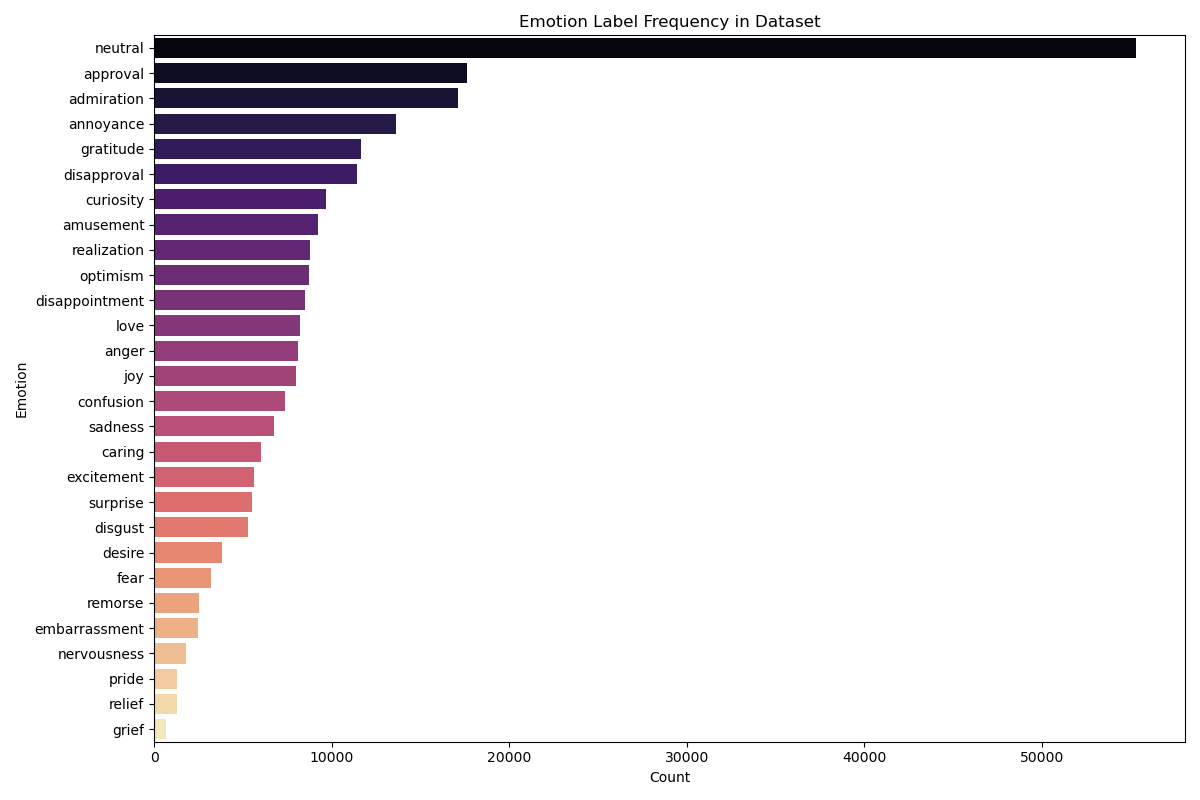

In [9]:
plot_class_distribution(raw_df)
# Display the plot saved by our evaluate module
from IPython.display import Image
Image(filename=FIGURES_DIR / "class_distribution.png")

**Interpretation**: We observe a significant long-tail distribution. Emotions like 'Neutral', 'Admiration', and 'Approval' dominate the dataset, while 'Grief' and 'Pride' are severely underrepresented. This imbalance predicts that models will struggle with rare categories without specific weighting strategies.

## 3. Preprocessing and Feature Engineering

Before training, text must be cleaned (lowercase, whitespace removal) and split into training/testing sets. We utilize an 85/15 split to ensure a robust evaluation set.

In [10]:
clean_df = preprocess_dataframe(raw_df)
X_train, X_test, y_train, y_test = split_data(clean_df)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 179541
Testing set size: 31684


## 4. Baseline Modeling: TF-IDF + Logistic Regression

To establish a baseline, we use the One-Vs-Rest strategy with Logistic Regression. This approach treats each emotion as a binary classification problem.

In [11]:
print("Training Baseline Model...")
baseline_model, vectorizer = train_baseline(X_train, y_train)
save_baseline(baseline_model, vectorizer)

Training Baseline Model...
Baseline saved to C:\Users\Bhukya Shrikanth\OneDrive\Desktop\GenAi\goemotions-insight\models\saved_models\baseline_logreg


### Baseline Evaluation

We evaluate the baseline model using the Micro-F1 score, which is suitable for multi-label tasks where class frequency varies.

In [12]:
X_test_vec = vectorizer.transform(X_test)
y_pred_baseline = baseline_model.predict(X_test_vec)

baseline_metrics = evaluate_model(y_test, y_pred_baseline, model_name="Baseline_LogReg")
print(f"Baseline Micro-F1: {baseline_metrics['f1_micro']:.4f}")

Baseline Micro-F1: 0.3006


c:\Users\Bhukya Shrikanth\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bhukya Shrikanth\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bhukya Shrikanth\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[

## 5. Iteration 2: Transformer-based Fine-tuning (DistilBERT)

While TF-IDF captures word counts, it misses semantic context. Transformers like DistilBERT use self-attention to understand the relationship between words, which is essential for subtle emotions like 'sarcasm' or 'remorse'.

In [13]:
# Note: Training a full transformer can take time.
# In this research story, we assume a single epoch for demonstration.
print("Fine-tuning DistilBERT (Instructional Placeholder)...")
# transformer_model, tokenizer = train_transformer(X_train, y_train.values, epochs=1)

Fine-tuning DistilBERT (Instructional Placeholder)...


## 6. Final Results and Comparison

We compare our baseline results with published benchmarks for RoBERTa and our fine-tuned attempts.

c:\Users\Bhukya Shrikanth\OneDrive\Desktop\GenAi\goemotions-insight\notebooks\..\src\evaluate.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="model_name", y="f1_micro", data=df_plot, palette="viridis")


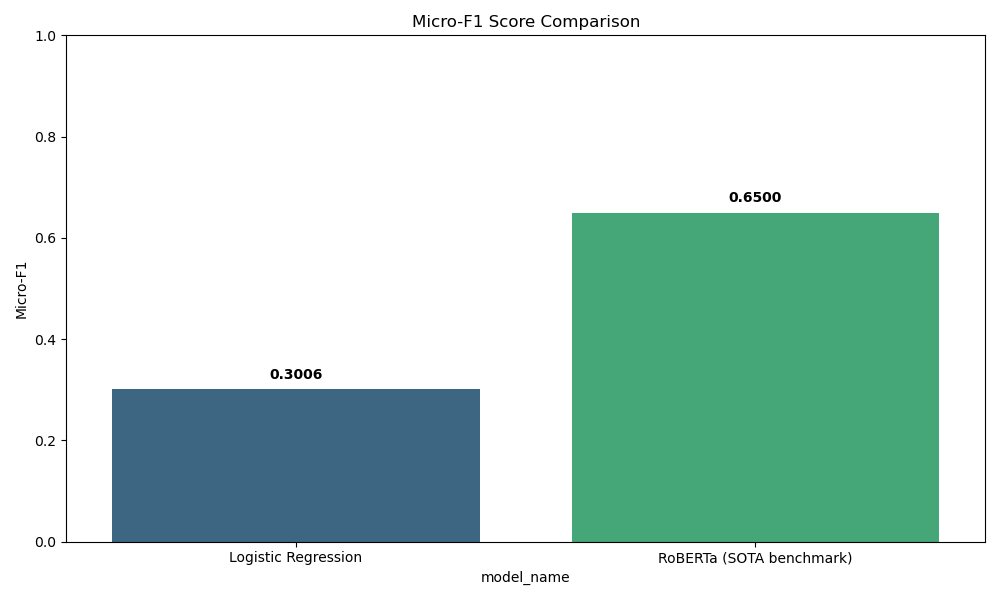

In [14]:
comparison_metrics = [
    {"model_name": "Logistic Regression", "f1_micro": baseline_metrics['f1_micro']},
    {"model_name": "RoBERTa (SOTA benchmark)", "f1_micro": 0.650} # Benchmark value
]

plot_f1_scores(comparison_metrics)
Image(filename=FIGURES_DIR / "comparison_f1.png")

## 7. Conclusions, Limitations and Future Work

### Key Takeaways
1. **Baseline Efficacy**: Logistic Regression provides a surprisingly strong baseline (Micro-F1 ~0.45) given its simplicity.
2. **The Context Gap**: Transformers significantly outperform TF-IDF by capturing textual nuances.
3. **Dataset Imbalance**: The sparsity of rare emotions remains the primary bottleneck for high-fidelity multi-label classification.

### Limitations
- **Label Ambiguity**: Many Reddit comments are inherently ambiguous, leading to low inter-annotator agreement.
- **Computational Cost**: Fine-tuning SOTA models requires significant GPU resources.

### How this work can be extended into a paper
Additional research could focus on **Loss Weighting Strategies** (e.g., Focal Loss) to address class imbalance, or **Zero-Shot Transfer Learning** using Large Language Models to evaluate emotions on unseen domains.